In [100]:
from ipywidgets import fixed, interact
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from typing import Dict

from hyperspace.backends import FHRRBackend
from hyperspace.core import (
    CleanupModule,
    MemoryStorageModule,
    PositionalEncoderModule,
    PositionalInversionModule,
    RegressionModule,
    ValueEncoderModule
)

In [101]:
EXP_CONFIG: Dict = {
    "num_training_points": 20,
    "num_gt_points": 100,
    "seed": 101,
    "x_dim_min": 0,
    "x_dim_max": 2 * np.pi,
    "test_size": 0.2
}

VSA_CONFIG: Dict = {
    "vector_dim": 2560,
    "vector_length_scale": 0.1,
    "device": "cpu"
}

In [102]:
# -----------------
# Generate GT Data
# -----------------
x_gt: np.ndarray = np.linspace(
    EXP_CONFIG["x_dim_min"],
    EXP_CONFIG["x_dim_max"],
    EXP_CONFIG["num_gt_points"]
)
y_gt: np.ndarray = np.sin(x_gt)

# normalize both axes to between [0, 1]
x_gt_norm = x_gt / EXP_CONFIG["x_dim_max"]
y_gt_norm = y_gt + 1
y_gt_norm /= 2

# updating types and shapes to conform to hyperspace's API

x_gt_norm: torch.Tensor = torch.from_numpy(x_gt_norm)
y_gt_norm: torch.Tensor = torch.from_numpy(y_gt_norm)

x_gt_norm = x_gt_norm.unsqueeze(-1)
y_gt_norm = y_gt_norm.unsqueeze(-1)

print(f"x_gt_norm type: {type(x_gt_norm)}; shape: {x_gt_norm.shape}")
print(f"y_gt_norm type: {type(y_gt_norm)}; shape: {y_gt_norm.shape}")

assert isinstance(x_gt_norm, torch.Tensor)
assert isinstance(y_gt_norm, torch.Tensor)
assert x_gt_norm.shape == (EXP_CONFIG["num_gt_points"], 1)
assert y_gt_norm.shape == (EXP_CONFIG["num_gt_points"], 1)

x_gt_norm type: <class 'torch.Tensor'>; shape: torch.Size([100, 1])
y_gt_norm type: <class 'torch.Tensor'>; shape: torch.Size([100, 1])


In [103]:
# ----------------------
# Generate Sampled Data
# ----------------------
x_Train: np.ndarray = np.linspace(
    EXP_CONFIG["x_dim_min"],
    EXP_CONFIG["x_dim_max"],
    EXP_CONFIG["num_training_points"]
)
y_Train: np.ndarray = np.sin(x_Train)

# normalize both axes to between [0, 1]
x_Train_norm: np.ndarray = x_Train / EXP_CONFIG["x_dim_max"]
y_Train_norm: np.ndarray = y_Train + 1
y_Train_norm /= 2

assert isinstance(x_Train_norm, np.ndarray)
assert isinstance(y_Train_norm, np.ndarray)
assert x_Train_norm.shape == (EXP_CONFIG["num_training_points"],)
assert y_Train_norm.shape == (EXP_CONFIG["num_training_points"],)

# updating types and shapes to conform to hyperspace's API

x_Train_norm: torch.Tensor = torch.from_numpy(x_Train_norm)
y_Train_norm: torch.Tensor = torch.from_numpy(y_Train_norm)

x_Train_norm = x_Train_norm.unsqueeze(-1)
y_Train_norm = y_Train_norm.unsqueeze(-1)

codebook_values = np.arange(0.9, 1.1, 100)
codebook_values = torch.from_numpy(codebook_values).unsqueeze(-1)

print(f"x_Train_norm type: {type(x_Train_norm)}; shape: {x_Train_norm.shape}")
print(f"y_Train_norm type: {type(y_Train_norm)}; shape: {y_Train_norm.shape}")

assert isinstance(x_Train_norm, torch.Tensor)
assert isinstance(y_Train_norm, torch.Tensor)
assert x_Train_norm.shape == (EXP_CONFIG["num_training_points"], 1)
assert y_Train_norm.shape == (EXP_CONFIG["num_training_points"], 1)

x_Train_norm type: <class 'torch.Tensor'>; shape: torch.Size([20, 1])
y_Train_norm type: <class 'torch.Tensor'>; shape: torch.Size([20, 1])


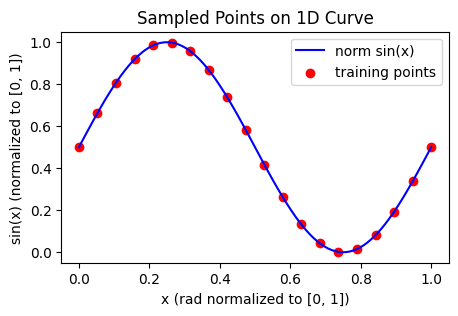

In [104]:
plt.figure(figsize=(5, 3))
plt.plot(x_gt_norm, y_gt_norm, label="norm sin(x)", color="blue")
plt.scatter(x_Train_norm, y_Train_norm, label="training points", color="red")
plt.title("Sampled Points on 1D Curve")
plt.xlabel("x (rad normalized to [0, 1])")
plt.ylabel("sin(x) (normalized to [0, 1])")
plt.legend()
plt.show()

In [105]:
# ----------------------------------------------------------------
# Adding offest to avoid identity problem with fractional binding
# ----------------------------------------------------------------
x_gt_norm += 10
x_Train_norm += 10
y_gt_norm += 10
y_Train_norm += 10

# hardcoding
y_axis = torch.arange(9, 12, 0.01).unsqueeze(-1)

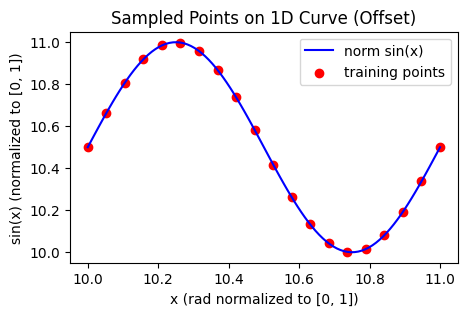

In [106]:
plt.figure(figsize=(5, 3))
plt.plot(x_gt_norm, y_gt_norm, label="norm sin(x)", color="blue")
plt.scatter(x_Train_norm, y_Train_norm, label="training points", color="red")
plt.title("Sampled Points on 1D Curve (Offset)")
plt.xlabel("x (rad normalized to [0, 1])")
plt.ylabel("sin(x) (normalized to [0, 1])")
plt.legend()
plt.show()

In [107]:
# ------------------------------
# Initialize HyperSpace Modules
# ------------------------------
fhrr_backend = FHRRBackend(
    vector_dim=VSA_CONFIG["vector_dim"],
    length_scale=VSA_CONFIG["vector_length_scale"],
    device=VSA_CONFIG["device"],
    seed=EXP_CONFIG["seed"]
)

In [108]:
# -----------------------------------------------------------------
# Encode the ground truth and sampling positions into vector space
# -----------------------------------------------------------------
x_gt_vectors, _ = fhrr_backend.positional_encoding(x_gt_norm)
x_Train_vectors, _ = fhrr_backend.positional_encoding(x_Train_norm)

x_gt_vectors, _ = fhrr_backend.normalize(x_gt_vectors)
x_Train_vectors, _ = fhrr_backend.normalize(x_Train_vectors)

print(f"x_gt_vectors type: {type(x_gt_vectors)}; shape: {x_gt_vectors.shape}")
print(f"x_Train_vectors type: {type(x_Train_vectors)}; shape: {x_Train_vectors.shape}")

assert isinstance(x_gt_vectors, torch.Tensor)
assert isinstance(x_Train_vectors, torch.Tensor)
assert x_gt_vectors.shape == (
    EXP_CONFIG["num_gt_points"],
    VSA_CONFIG["vector_dim"]
)
assert x_Train_vectors.shape == (
    EXP_CONFIG["num_training_points"],
    VSA_CONFIG["vector_dim"]
)

x_gt_vectors type: <class 'torch.Tensor'>; shape: torch.Size([100, 2560])
x_Train_vectors type: <class 'torch.Tensor'>; shape: torch.Size([20, 2560])


X Sims Min: -0.1962450308661455; Max: 0.9999999999990021


Text(0, 0.5, 'Sample Idx')

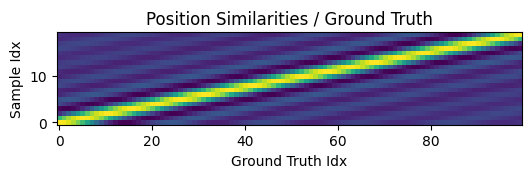

In [109]:
x_sims, _ = fhrr_backend.similarity(x_gt_vectors, x_Train_vectors)

print(f"X Sims Min: {torch.min(x_sims)}; Max: {torch.max(x_sims)}")

plt.figure(figsize=(6, 2))
plt.imshow(x_sims.T, origin="lower")
plt.title("Position Similarities / Ground Truth")
plt.xlabel("Ground Truth Idx")
plt.ylabel("Sample Idx")

In [110]:
# -----------------------------------------------------------------
# Encode the ground truth and sampling values into vector space
# -----------------------------------------------------------------
y_gt_vectors, _ = fhrr_backend.value_encoding(y_gt_norm)
y_Train_vectors, _ = fhrr_backend.value_encoding(y_Train_norm)
y_axis_vectors, _ = fhrr_backend.value_encoding(y_axis)

y_gt_vectors, _ = fhrr_backend.normalize(y_gt_vectors)
y_Train_vectors, _ = fhrr_backend.normalize(y_Train_vectors)
y_axis_vectors, _ = fhrr_backend.normalize(y_axis_vectors)
# y_axis_vectors = y_axis_vectors.double()

print(f"y_gt_vectors type: {type(y_gt_vectors)}; shape: {y_gt_vectors.shape}")
print(f"y_Train_vectors type: {type(y_Train_vectors)}; shape: {y_Train_vectors.shape}")
print(f"y_axis_vectors type: {type(y_axis_vectors)}; shape: {y_axis_vectors.shape}")

assert isinstance(y_gt_vectors, torch.Tensor)
assert isinstance(y_Train_vectors, torch.Tensor)
assert isinstance(y_axis_vectors, torch.Tensor)
assert y_gt_vectors.shape == (
    EXP_CONFIG["num_gt_points"],
    VSA_CONFIG["vector_dim"]
)
assert y_Train_vectors.shape == (
    EXP_CONFIG["num_training_points"],
    VSA_CONFIG["vector_dim"]
)

y_gt_vectors type: <class 'torch.Tensor'>; shape: torch.Size([100, 2560])
y_Train_vectors type: <class 'torch.Tensor'>; shape: torch.Size([20, 2560])
y_axis_vectors type: <class 'torch.Tensor'>; shape: torch.Size([300, 2560])


Y Sims Min: -0.2162088614163956; Max: 0.999999999969719


<Figure size 300x300 with 0 Axes>

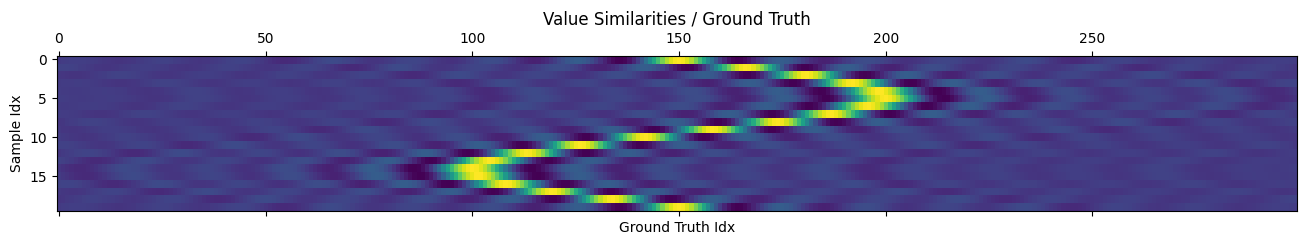

In [111]:
y_sims, _ = fhrr_backend.similarity(y_axis_vectors.cdouble(), y_Train_vectors)

print(f"Y Sims Min: {torch.min(y_sims)}; Max: {torch.max(y_sims)}")

plt.figure(figsize=(3, 3))
plt.matshow(y_sims.T, aspect="auto")
plt.title("Value Similarities / Ground Truth")
plt.xlabel("Ground Truth Idx")
plt.ylabel("Sample Idx")

del y_sims

In [112]:
# ------------------------------
# Initialize HyperSpace Modules
# ------------------------------
cleanup_module = CleanupModule(
    backend=fhrr_backend,
    values=y_axis
)
memory_storage_module = MemoryStorageModule(
    backend=fhrr_backend
)
positional_encoder_module = PositionalEncoderModule(
    backend=fhrr_backend,
)
positional_inversion_module = PositionalInversionModule(
    backend=fhrr_backend,
    positions=x_Train_norm
)
codebook, _ = fhrr_backend.value_encoding(y_axis)
regression_module = RegressionModule(
    backend=fhrr_backend,
    codebook=codebook,
    values=y_axis
)
value_encoder_module = ValueEncoderModule(
    backend=fhrr_backend
)

In [113]:
# ------------------------------------------------------------
# Evaluate the similarities binded position and value vectors
# with respect to the gt position and value vectors
# ------------------------------------------------------------
sampled_pv_matrix = torch.zeros(( # sampled positions, sampled values, vector_dim
    EXP_CONFIG["num_training_points"],
    EXP_CONFIG["num_training_points"],
    VSA_CONFIG["vector_dim"],
), dtype=torch.cdouble)
sampled_vs_versus_positions = torch.zeros(( # sampled positions, sampled values, gt_positions
    EXP_CONFIG["num_training_points"],
    EXP_CONFIG["num_training_points"],
    EXP_CONFIG["num_gt_points"]    
))
sampled_vs_versus_values = torch.zeros(( # sampled positions, sampled values, gt_values
    EXP_CONFIG["num_training_points"],
    EXP_CONFIG["num_training_points"],
    EXP_CONFIG["num_gt_points"]    
))

# Bind all positions and values together
for p_i in range(EXP_CONFIG["num_training_points"]):
    for v_i in range(EXP_CONFIG["num_training_points"]):
        
        pv = x_Train_vectors[p_i]
        vv = y_Train_vectors[v_i]
        pvv, _ = fhrr_backend.bind(vv, pv)
        sampled_pv_matrix[p_i, v_i] = pvv

# Compute similarities with all gt positions
for p_i in range(EXP_CONFIG["num_training_points"]):
    for v_i in range(EXP_CONFIG["num_training_points"]):
        for gt_i in range(EXP_CONFIG["num_gt_points"]):
            pv = sampled_pv_matrix[p_i, v_i]
            gt_v = x_gt_vectors[gt_i]
            s, _ = fhrr_backend.similarity(pv, gt_v)
            sampled_vs_versus_positions[p_i, v_i, gt_i] = s

# Compute similarities with all gt values
for p_i in range(EXP_CONFIG["num_training_points"]):
    for v_i in range(EXP_CONFIG["num_training_points"]):
        for gt_i in range(EXP_CONFIG["num_gt_points"]):
            pv = sampled_pv_matrix[p_i, v_i]
            gt_v = y_gt_vectors[gt_i]
            s, _ = fhrr_backend.similarity(pv, gt_v)
            sampled_vs_versus_values[p_i, v_i, gt_i] = s

print(f"Value Sims Min: {torch.min(sampled_vs_versus_values)}; Max: {torch.max(sampled_vs_versus_values)}")
print(f"Position Sims Min: {torch.min(sampled_vs_versus_positions)}; Max: {torch.max(sampled_vs_versus_positions)}")

Value Sims Min: -0.03645238280296326; Max: 0.06077202782034874
Position Sims Min: -0.04583948105573654; Max: 0.04351767897605896


In [114]:
def plot_slice(slice_index, m, t):
    plt.clf()
    plt.title(t)
    plt.imshow(m[:, :, slice_index], vmin=0.0, vmax=1.0)
    plt.xlabel("Value Index")
    plt.ylabel("Position Index")
    plt.show()

def plot_interactive_slice(m, t):
    interact(
        plot_slice,
        slice_index=(0, m.shape[-1] - 1),
        m=fixed(m),
        t=fixed(t)
    )

In [115]:
plot_interactive_slice(sampled_vs_versus_positions, "PV Vectors / Positions")

interactive(children=(IntSlider(value=49, description='slice_index', max=99), Output()), _dom_classes=('widget…

In [116]:
plot_interactive_slice(sampled_vs_versus_values, "PV Vectors / Values")

interactive(children=(IntSlider(value=49, description='slice_index', max=99), Output()), _dom_classes=('widget…

In [117]:
del (
    sampled_pv_matrix,
    sampled_vs_versus_positions,
    sampled_vs_versus_values
)

In [118]:
# -------------------------------------------------------------------
# Experimenting with < 1 FPE producing identity vectors when binding
# -------------------------------------------------------------------

p, _ = fhrr_backend.positional_encoding(torch.tensor([1]))
v, _ = fhrr_backend.value_encoding(torch.tensor([1]))


pv, _ = fhrr_backend.bind(p, v)

print(f"SIM(p, v)       : {fhrr_backend.similarity(p, v)[0]}")
print(f"SIM(p, p bind v): {fhrr_backend.similarity(p, pv)[0]}")
print(f"SIM(v, p bind v): {fhrr_backend.similarity(v, pv)[0]}")

p, _ = fhrr_backend.positional_encoding(torch.tensor([1]))
v, _ = fhrr_backend.value_encoding(torch.tensor([1]))

print(f"\n Encoding < 1:")

p, _ = fhrr_backend.positional_encoding(torch.tensor([0.1]))
v, _ = fhrr_backend.value_encoding(torch.tensor([1]))

pv, _ = fhrr_backend.bind(p, v)

print(f"SIM(p, v)       : {fhrr_backend.similarity(p, v)[0]}")
print(f"SIM(p, p bind v): {fhrr_backend.similarity(p, pv)[0]}")
print(f"SIM(v, p bind v): {fhrr_backend.similarity(v, pv)[0]}")

print(f"\n Encoding > 1:")

p, _ = fhrr_backend.positional_encoding(torch.tensor([10]))
v, _ = fhrr_backend.value_encoding(torch.tensor([1]))

pv, _ = fhrr_backend.bind(p, v)

print(f"SIM(p, v)       : {fhrr_backend.similarity(p, v)[0]}")
print(f"SIM(p, p bind v): {fhrr_backend.similarity(p, pv)[0]}")
print(f"SIM(v, p bind v): {fhrr_backend.similarity(v, pv)[0]}")

del p, v, pv

SIM(p, v)       : 0.0004277355910744518
SIM(p, p bind v): -0.028398143127560616
SIM(v, p bind v): -0.02410328947007656

 Encoding < 1:
SIM(p, v)       : -0.00602877140045166
SIM(p, p bind v): -0.028384443372488022
SIM(v, p bind v): 0.012377824634313583

 Encoding > 1:
SIM(p, v)       : 0.002816116437315941
SIM(p, p bind v): -0.028520900756120682
SIM(v, p bind v): 0.008684304542839527


In [119]:
# --------------------------------------------------------------------------------
# Now that we have validated the individual value and positional encoding module,
# we will leverage the HyperSpace modules to simplify this process for us
# --------------------------------------------------------------------------------
positional_encodings, _ = positional_encoder_module(x_Train_norm)
value_encodings, _ = value_encoder_module(y_Train_norm)
memory, _ = memory_storage_module(
    p_vectors=positional_encodings,
    v_vectors=value_encodings
)

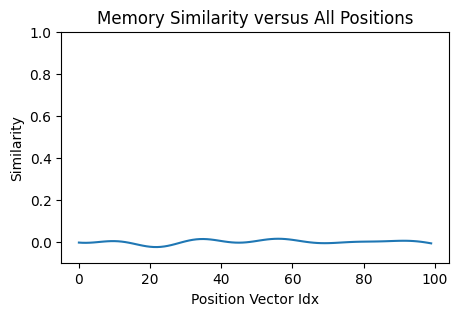

In [120]:
# ---------------------------------------------------------------------
# compare the memory with respect to all ground truth position vectors
# ---------------------------------------------------------------------
m_to_pv_sims, _ = fhrr_backend.similarity(memory, x_gt_vectors)

x = torch.arange(0, m_to_pv_sims.shape[0]).cpu().numpy()

plt.figure(figsize=(5, 3))
plt.plot(x, m_to_pv_sims)
plt.xlabel("Position Vector Idx")
plt.ylabel("Similarity")
plt.ylim(-0.1, 1)
plt.title("Memory Similarity versus All Positions")

del x, m_to_pv_sims

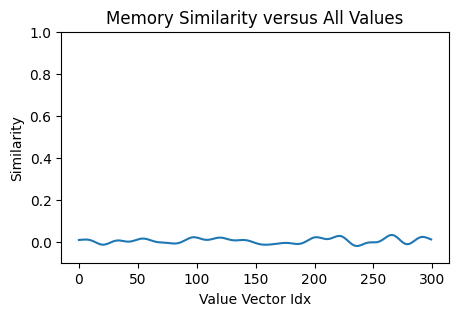

In [121]:
# ---------------------------------------------------------------------
# compare the memory with respect to all ground truth value vectors
# ---------------------------------------------------------------------

m_to_vv_sims, _ = fhrr_backend.similarity(memory, y_axis_vectors.to(dtype=torch.cdouble))

x = torch.arange(0, m_to_vv_sims.shape[0]).cpu().numpy()

plt.figure(figsize=(5, 3))
plt.plot(x, m_to_vv_sims)
plt.xlabel("Value Vector Idx")
plt.ylabel("Similarity")
plt.ylim(-0.1, 1)
plt.title("Memory Similarity versus All Values")

del x, m_to_vv_sims

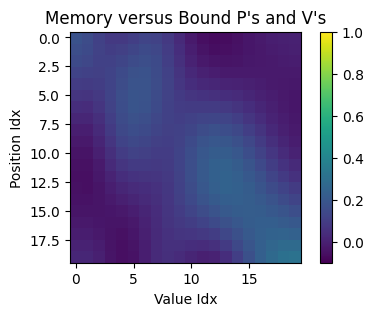

In [122]:
# ----------------------------------------------------------------------------------
# compare the memory with respect to all possible binded position and value vectors
# ----------------------------------------------------------------------------------
pv_sims = torch.zeros((
    EXP_CONFIG["num_training_points"],
    EXP_CONFIG["num_training_points"],
))
for pv_idx in range(EXP_CONFIG["num_training_points"]):
    for vv_idx in range(EXP_CONFIG["num_training_points"]):
        bpv, _ = fhrr_backend.bind(
            a=x_gt_vectors[pv_idx],
            b=y_gt_vectors[vv_idx]
        )
        s, _ = fhrr_backend.similarity(memory, bpv)
        pv_sims[pv_idx, vv_idx] = s

plt.figure(figsize=(5,3))
plt.imshow(pv_sims, vmin=-0.1, vmax=1.0)
plt.ylabel("Position Idx")
plt.xlabel("Value Idx")
plt.title("Memory versus Bound P's and V's")
plt.colorbar()
plt.show()

del pv_sims

In [123]:
# -----------------------------------------------------------------
# Unbind the memory with all desired positions to hopefully return
# higher quality position-wise value vectors
# -----------------------------------------------------------------
pi_memory, pi_info = positional_inversion_module(memory)

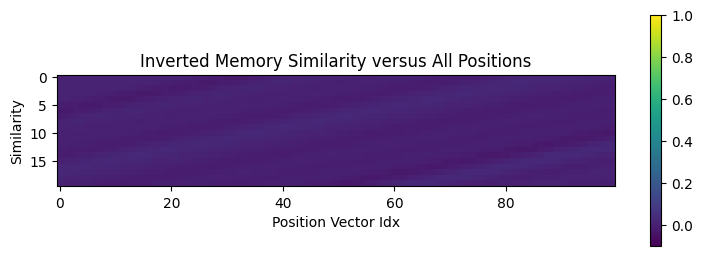

In [124]:
# ---------------------------------------------------------------------
# compare the inverted memory with respect to all
# ground truth position vectors
# ---------------------------------------------------------------------
m_to_pv_sims, _ = fhrr_backend.similarity(pi_memory, x_gt_vectors)

x = torch.arange(0, m_to_pv_sims.shape[0]).cpu().numpy()

plt.figure(figsize=(9, 3))
plt.imshow(m_to_pv_sims, vmin=-0.1, vmax=1.0)
plt.xlabel("Position Vector Idx")
plt.ylabel("Similarity")
plt.colorbar()
plt.title("Inverted Memory Similarity versus All Positions")

del x, m_to_pv_sims

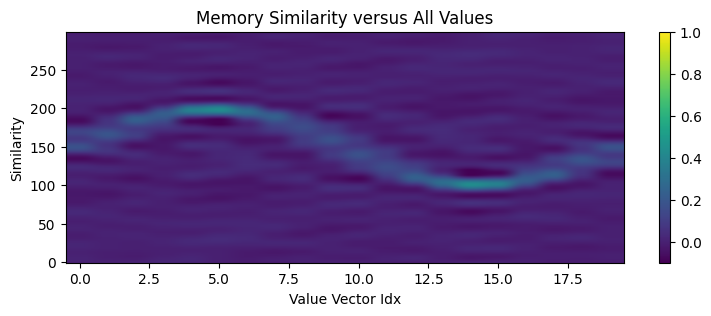

In [125]:
# ---------------------------------------------------------------------
# compare the inverted memory with respect to all
# ground truth value vectors
# ---------------------------------------------------------------------

m_to_vv_sims, _ = fhrr_backend.similarity(pi_memory, y_axis_vectors.to(dtype=torch.cdouble))

x = torch.arange(0, m_to_vv_sims.shape[0]).cpu().numpy()

plt.figure(figsize=(9, 3))
plt.imshow(m_to_vv_sims.T, vmin=-0.1, vmax=1.0, aspect="auto", origin="lower")
plt.xlabel("Value Vector Idx")
plt.ylabel("Similarity")
plt.colorbar()
plt.title("Memory Similarity versus All Values")

del x, m_to_vv_sims

In [126]:
# -------------------------------
# cleanup with resonator
# -------------------------------
resonator_cm = CleanupModule(
    backend=fhrr_backend,
    codebook=codebook,
    # values=torch.arange(9, 12, step=0.01).unsqueeze(-1),
    method="resonator"
)

In [127]:
res_cleaned_memory, res_info = resonator_cm(
    pi_memory.to(dtype=torch.cfloat),
    num_iters=6
)

In [128]:
res_history = res_info['sims_history']

print(f"History Length: {len(res_history)}")
print(f"History Shape: {res_history[0].shape}")

def plot_slice(timestep, history):
    plt.clf()
    plt.title("Resonator Cleanup")
    plt.imshow(history[timestep].T, vmin=-0.1, vmax=1.0, aspect="auto", origin="lower")
    plt.xlabel("Codebook Index")
    plt.ylabel("Decoded Position Index")
    plt.show()

def plot_interactive_slice(h):
    interact(
        plot_slice,
        timestep=(0, len(h) - 1),
        history=fixed(h),
    )

plot_interactive_slice(res_history)

History Length: 6
History Shape: torch.Size([20, 300])


interactive(children=(IntSlider(value=2, description='timestep', max=5), Output()), _dom_classes=('widget-inte…

In [129]:
# -------------------------------
# cleanup with hopfield
# -------------------------------
hopfield_cm = CleanupModule(
    backend=fhrr_backend,
    codebook=codebook.to(dtype=torch.cdouble),
    # values=torch.arange(9, 12, step=0.05).unsqueeze(-1),
    method="modern_hopfield"
)

In [130]:
mhn_cleaned_memory, mhn_info = hopfield_cm(
    pi_memory.to(dtype=torch.cdouble),
    num_iters=100,
    temperature=0.1
)

In [131]:
mhn_history = mhn_info['attn_history']

print(f"History Length: {len(mhn_history)}")
print(f"History Shape: {mhn_history[0].shape}")

def plot_slice(timestep, history):
    plt.clf()
    plt.title("Hopfield Attention")
    plt.imshow(history[timestep].T, vmin=-0.1, vmax=1.0, aspect="auto", origin="lower")
    plt.xlabel("Codebook Index")
    plt.ylabel("Decoded Value Index")
    plt.show()

def plot_interactive_slice(h):
    interact(
        plot_slice,
        timestep=(0, len(h) - 1),
        history=fixed(h),
    )

plot_interactive_slice(mhn_history)

History Length: 100
History Shape: torch.Size([20, 300])


interactive(children=(IntSlider(value=49, description='timestep', max=99), Output()), _dom_classes=('widget-in…

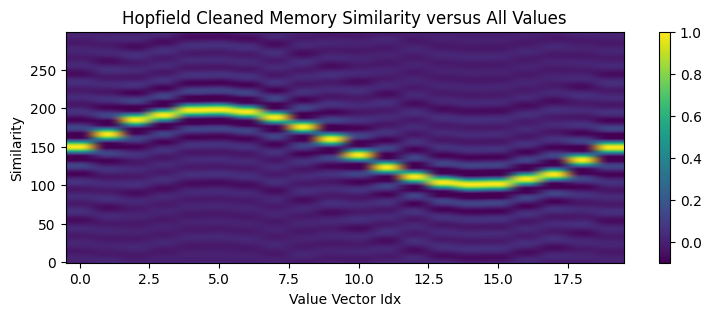

In [132]:
# ---------------------------------------------------------------------
# compare the cleaned memory from the hopfield network
# with respect to all ground truth value vectors
# ---------------------------------------------------------------------

hcm_to_vv_sims, _ = fhrr_backend.similarity(mhn_cleaned_memory.cfloat(), y_axis_vectors)

x = torch.arange(0, hcm_to_vv_sims.shape[0]).cpu().numpy()

plt.figure(figsize=(9, 3))
plt.imshow(hcm_to_vv_sims.T, vmin=-0.1, vmax=1.0, aspect="auto", origin="lower")
plt.xlabel("Value Vector Idx")
plt.ylabel("Similarity")
plt.colorbar()
plt.title("Hopfield Cleaned Memory Similarity versus All Values")

del x, hcm_to_vv_sims

In [133]:
# ------------------------------------------------------
# create the regression modules for codebook and neural
# network regression
# ------------------------------------------------------
codebook_rm = RegressionModule(
    backend=fhrr_backend,
    codebook=codebook,
    values=y_axis,
    method="codebook"
)
neural_rm = RegressionModule(
    backend=fhrr_backend,
    codebook=codebook,
    values=y_axis,
    method="neural"
)

In [134]:
# -----------------------------
# build the regression network
# -----------------------------
import torch.nn as nn
from hyperspace.core.regression.models import DenseLinearModel

regression_model = DenseLinearModel(
    feature_dim=VSA_CONFIG["vector_dim"],
    value_dim=1,
    num_layers=2,
    hidden_size=512,
    hidden_act=nn.ReLU(),
)

In [135]:
# ------------------------------------------------
# create the training data for the neural network
# ------------------------------------------------
num_samples: int = y_axis.shape[0]
sample_idxs: np.ndarray = np.arange(0, num_samples - 1)
np.random.shuffle(sample_idxs)

num_test_samples: int = int(num_samples * EXP_CONFIG["test_size"])
network_Train_vectors = y_axis_vectors[sample_idxs[num_test_samples:]]
network_Test_vectors = y_axis_vectors[sample_idxs[:num_test_samples]]
network_Train_outputs = y_axis[sample_idxs[num_test_samples:]]
network_Test_outputs = y_axis[sample_idxs[:num_test_samples]]

print(f"Num Samples: {num_samples}")
print(f"Num Train Vectors: {network_Train_vectors.shape[0]}")
print(f"Num Test Vectors: {network_Test_vectors.shape[0]}")
print(f"Num Train Outputs: {network_Train_outputs.shape[0]}")
print(f"Num Test Outputs: {network_Test_outputs.shape[0]}")
print()
print(f"Train Output Range: {torch.min(network_Train_outputs):.4f} to {torch.max(network_Train_outputs):.4f}.")
print(f"Test Output Range: {torch.min(network_Test_outputs):.4f} to {torch.max(network_Test_outputs):.4f}.")

Num Samples: 300
Num Train Vectors: 239
Num Test Vectors: 60
Num Train Outputs: 239
Num Test Outputs: 60

Train Output Range: 9.0000 to 11.9800.
Test Output Range: 9.0500 to 11.9400.


In [136]:
# ----------------------------------------
# normalize the training and testing data
# ----------------------------------------
y_train = network_Train_outputs.float()
y_test  = network_Test_outputs.float()

# compute stats on TRAIN ONLY
y_mean = y_train.mean()
y_std  = y_train.std(unbiased=False).clamp_min(1e-8)  # avoid divide-by-zero

# normalize
y_train_norm = (y_train - y_mean) / y_std
y_test_norm  = (y_test  - y_mean) / y_std

# helpers for later
def denorm(y_norm: torch.Tensor) -> torch.Tensor:
    return y_norm * y_std + y_mean

print("Train norm range:", y_train_norm.min().item(), "to", y_train_norm.max().item())
print("Test  norm range:", y_test_norm.min().item(),  "to", y_test_norm.max().item())


Train norm range: -1.7677356004714966 to 1.6582533121109009
Test  norm range: -1.710252285003662 to 1.6122679710388184


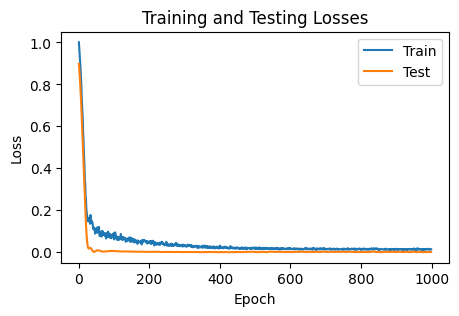

In [137]:
# ------------------------------------------
# train and validate the regression network
# ------------------------------------------
optimizer = torch.optim.Adam(
    regression_model.parameters(),
    lr=1e-3
)
loss_func = nn.MSELoss()

train_losses: list = []
test_losses: list = []

num_epochs: int = 1000
noise_std = 0.05

def prepare_complex_input(v: torch.Tensor) -> torch.Tensor:
    """Flatten complex vectors for neural network input."""
    real_part = torch.real(v)
    imag_part = torch.imag(v)
    return imag_part
    return torch.cat([real_part, imag_part], dim=-1)

for i in range(num_epochs):
    # ---------
    # Training
    # ---------
    regression_model.train()

    inputs_flat = prepare_complex_input(network_Train_vectors)
    noise = noise_std * torch.randn_like(inputs_flat)
    noisy_inputs = inputs_flat + noise

    outputs = regression_model(noisy_inputs)
    train_loss = loss_func(outputs, y_train_norm)

    train_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    train_losses.append(train_loss.item())

    # -----------
    # Evaluation
    # -----------
    regression_model.eval()

    with torch.no_grad():

        test_inputs_flat = prepare_complex_input(network_Test_vectors)
        outputs = regression_model(test_inputs_flat)
        val_loss = loss_func(outputs, y_test_norm)
        test_losses.append(val_loss.item())

plt.figure(figsize=(5, 3))
plt.plot(train_losses, label="Train")
plt.plot(test_losses, label="Test")
plt.title("Training and Testing Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [138]:
# ---------------------------------------------
# load the trained regression model within the
# neural regression module
# ---------------------------------------------
neural_rm.load_neural_network(regression_model)

In [139]:
# ----------------------------------------
# regression with no cleanup and codebook
# ----------------------------------------
codebook_no_clean_output, _ = codebook_rm(v=pi_memory.cfloat())

print(f"Output Shape: {codebook_no_clean_output.shape}")
print(f"Output Range: {torch.min(codebook_no_clean_output):.4f} - {torch.max(codebook_no_clean_output):.4f}")

codebook_no_clean_mse = F.mse_loss(y_Train_norm, codebook_no_clean_output)
print(f"MSE: {codebook_no_clean_mse:.4f}")

Output Shape: torch.Size([20, 1])
Output Range: 10.1978 - 10.7985
MSE: 0.0462


In [140]:
# ----------------------------------------------
# regression with no cleanup and neural network
# ----------------------------------------------
with torch.no_grad():
    neural_no_clean_output, _ = neural_rm(v=torch.imag(pi_memory).float())

print(f"Output Shape: {neural_no_clean_output.shape}")
print(f"Output Range (Norm): {torch.min(neural_no_clean_output):.4f} - {torch.max(neural_no_clean_output):.4f}")

neural_no_clean_output_denorm = denorm(neural_no_clean_output)

print(f"Output Shape: {neural_no_clean_output_denorm.shape}")
print(f"Output Range (DeNorm): {torch.min(neural_no_clean_output_denorm):.4f} - {torch.max(neural_no_clean_output_denorm):.4f}")

neural_no_clean_mse = F.mse_loss(y_Train_norm, neural_no_clean_output_denorm)
print(f"MSE: {neural_no_clean_mse:.4f}")

Output Shape: torch.Size([20, 1])
Output Range (Norm): -71.3645 - 56.8679
Output Shape: torch.Size([20, 1])
Output Range (DeNorm): -51.5368 - 60.0025
MSE: 908.8011


In [141]:
# ----------------------------------------------
# regression with resonator and codebook
# ----------------------------------------------
codebook_resonator_output, _ = codebook_rm(v=res_cleaned_memory.cfloat())

print(f"Output Shape: {codebook_resonator_output.shape}")
print(f"Output Range: {torch.min(codebook_resonator_output):.4f} - {torch.max(codebook_resonator_output):.4f}")

codebook_resonator_mse = F.mse_loss(y_Train_norm, codebook_resonator_output)
print(f"MSE: {codebook_resonator_mse:.4f}")

Output Shape: torch.Size([20, 1])
Output Range: 10.0216 - 10.9782
MSE: 0.0003


In [142]:
# ----------------------------------------------
# regression with resonator and neural network
# ----------------------------------------------
neural_resonator_output, _ = neural_rm(v=torch.imag(res_cleaned_memory).float())

print(f"Output Shape: {neural_resonator_output.shape}")
print(f"Output Range (Norm): {torch.min(neural_resonator_output):.4f} - {torch.max(neural_resonator_output):.4f}")

neural_resonator_output_denorm = denorm(neural_resonator_output)

print(f"Output Shape: {neural_resonator_output_denorm.shape}")
print(f"Output Range (DeNorm): {torch.min(neural_resonator_output_denorm):.4f} - {torch.max(neural_resonator_output_denorm):.4f}")

neural_resonator_mse = F.mse_loss(y_Train_norm, neural_resonator_output_denorm)
print(f"MSE: {neural_resonator_mse:.4f}")

Output Shape: torch.Size([20, 1])
Output Range (Norm): -0.6193 - 0.5459
Output Shape: torch.Size([20, 1])
Output Range (DeNorm): 9.9990 - 11.0125
MSE: 0.0018


In [143]:
# ----------------------------------------------
# regression with hopfield and codebook
# ----------------------------------------------
codebook_hopfield_output, _ = codebook_rm(v=mhn_cleaned_memory.cfloat())

print(f"Output Shape: {codebook_hopfield_output.shape}")
print(f"Output Range: {torch.min(codebook_hopfield_output):.4f} - {torch.max(codebook_hopfield_output):.4f}")

codebook_hopfield_mse = F.mse_loss(y_Train_norm, codebook_hopfield_output)
print(f"MSE: {codebook_hopfield_mse:.4f}")

Output Shape: torch.Size([20, 1])
Output Range: 10.0156 - 10.9843
MSE: 0.0004


In [144]:
# ----------------------------------------------
# regression with hopfield and neural network
# ----------------------------------------------
neural_hopfield_output, _ = neural_rm(v=torch.imag(mhn_cleaned_memory).float())

print(f"Output Shape: {neural_hopfield_output.shape}")
print(f"Output Range (Norm): {torch.min(neural_hopfield_output):.4f} - {torch.max(neural_hopfield_output):.4f}")

neural_hopfield_output_denorm = denorm(neural_hopfield_output)

print(f"Output Shape: {neural_hopfield_output_denorm.shape}")
print(f"Output Range (DeNorm): {torch.min(neural_hopfield_output_denorm):.4f} - {torch.max(neural_hopfield_output_denorm):.4f}")

neural_hopfield_mse = F.mse_loss(y_Train_norm, neural_hopfield_output_denorm)
print(f"MSE: {neural_hopfield_mse:.4f}")

Output Shape: torch.Size([20, 1])
Output Range (Norm): -0.6906 - 0.5505
Output Shape: torch.Size([20, 1])
Output Range (DeNorm): 9.9369 - 11.0165
MSE: 0.0026


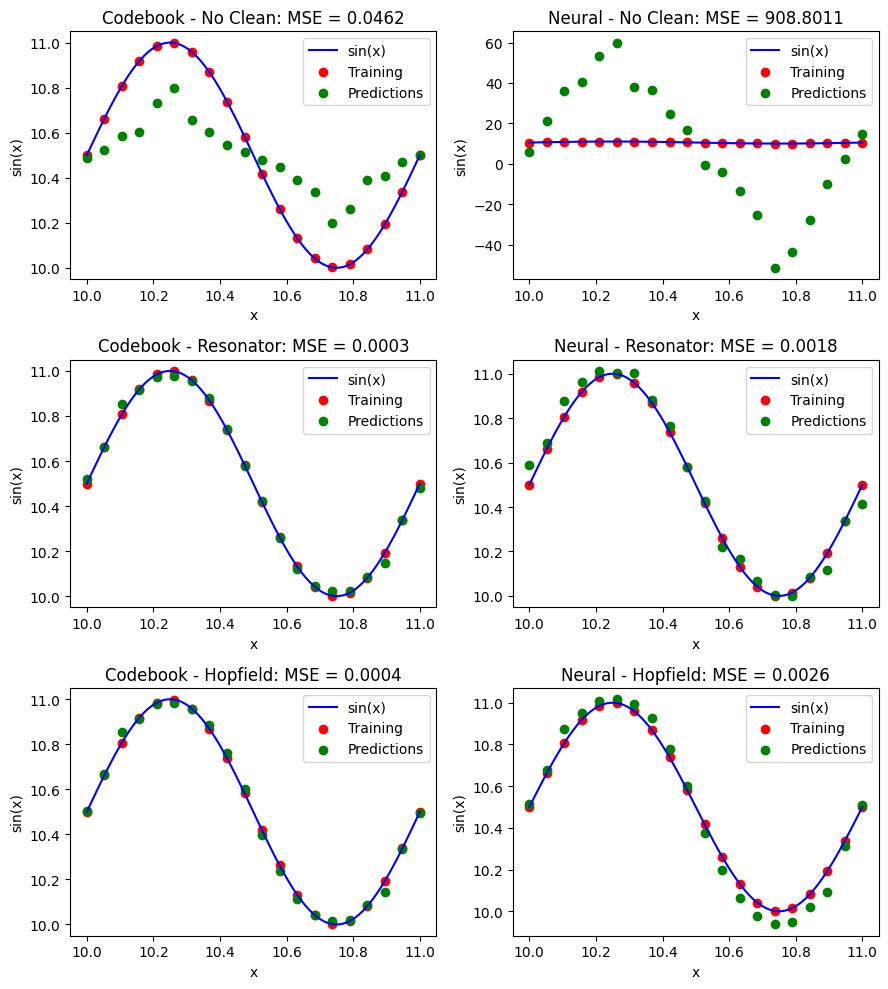

In [145]:
# ----------------------------------------------
# visualize and overlay regressed curves
# ----------------------------------------------
num_rows: int = 3
num_cols: int = 2
fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_rows * 3, num_cols * 5))

for i in range(num_rows):
    for j in range(num_cols):
        axs[i][j].set_xlabel("x")
        axs[i][j].set_ylabel("sin(x)")
        axs[i][j].plot(x_gt_norm, y_gt_norm, label="sin(x)", color="blue")
        axs[i][j].scatter(x_Train_norm, y_Train_norm, label="Training", color="red")

# plot codebook with no cleanup
i, j = 0, 0
axs[i, j].set_title(f"Codebook - No Clean: MSE = {codebook_no_clean_mse:.4f}")
y = codebook_no_clean_output.squeeze(-1).detach().cpu().numpy()
axs[i, j].scatter(x_Train_norm, y, label="Predictions", c="green")
axs[i][j].legend()

# plot network with no cleanup
i, j = 0, 1
axs[i, j].set_title(f"Neural - No Clean: MSE = {neural_no_clean_mse:.4f}")
y = neural_no_clean_output_denorm.squeeze(-1).detach().cpu().numpy()
axs[i, j].scatter(x_Train_norm, y, label="Predictions", c="green")
axs[i][j].legend()

# plot codebook with resonator
i, j = 1, 0
axs[i, j].set_title(f"Codebook - Resonator: MSE = {codebook_resonator_mse:.4f}")
y = codebook_resonator_output.squeeze(-1).detach().cpu().numpy()
axs[i, j].scatter(x_Train_norm, y, label="Predictions", c="green")
axs[i][j].legend()

# plot network with resonator
i, j = 1, 1
axs[i, j].set_title(f"Neural - Resonator: MSE = {neural_resonator_mse:.4f}")
y = neural_resonator_output_denorm.squeeze(-1).detach().cpu().numpy()
axs[i, j].scatter(x_Train_norm, y, label="Predictions", c="green")
axs[i][j].legend()

# plot codebook with hopfield
i, j = 2, 0
axs[i, j].set_title(f"Codebook - Hopfield: MSE = {codebook_hopfield_mse:.4f}")
y = codebook_hopfield_output.squeeze(-1).detach().cpu().numpy()
axs[i, j].scatter(x_Train_norm, y, label="Predictions", c="green")
axs[i][j].legend()

# plot network with hopfield
i, j = 2, 1
axs[i, j].set_title(f"Neural - Hopfield: MSE = {neural_hopfield_mse:.4f}")
y = neural_hopfield_output_denorm.squeeze(-1).detach().cpu().numpy()
axs[i, j].scatter(x_Train_norm, y, label="Predictions", c="green")
axs[i][j].legend()

plt.tight_layout()